# Actividad 2. Modelado predictivo y clasificación de riesgo con casos de dengue en México

**Valor:** 25% de la evaluación


## Objetivo

Aplicar técnicas de modelado predictivo y clasificación supervisada a una serie temporal de casos semanales de dengue en México, utilizando modelos base, regresión lineal, árboles de decisión y Random Forest.

La base de datos contiene casos semanales de dengue por entidad federativa entre 2020 y 2025.


## 1. Carga y exploración de datos


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [78]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/casos_dengue_2020-2025.csv"
df = pd.read_csv(ruta)
print("Tabla importada")
display(df.head())

Tabla importada


,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,QUINTANA ROO,SAN LUIS POTOSI,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ,YUCATAN,ZACATECAS
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,106,47,40,8,112,111,0,249,58,3
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,167,74,46,13,158,206,0,441,62,0
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,158,80,48,12,166,190,0,412,73,2
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,130,53,54,13,167,191,1,418,54,1
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,99,43,48,9,139,173,1,322,45,1


In [79]:
print("El dataframe tiene ", df.shape[0], " filas y ", df.shape[1] , " columnas." )

El dataframe tiene  282  filas y  33  columnas.


In [80]:
print("Columnas del dataframe")
df.columns

Columnas del dataframe


Index(['FECHA', 'AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR',
       'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA',
       'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO',
       'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON',
       'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI',
       'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ',
       'YUCATAN', 'ZACATECAS'],
      dtype='str')

In [81]:
df["FECHA"] = pd.to_datetime(df["FECHA"])
fecha_inicio = df["FECHA"].min()
fecha_fin = df["FECHA"].max()
print(f"El dataframe cubre desde el {fecha_inicio.date()} al {fecha_fin.date()}")

El dataframe cubre desde el 2020-01-05 al 2025-05-25


In [82]:
print("Valores faltantes")
df_faltantes = df.isna().sum()
df_faltantes = df_faltantes[df_faltantes > 0]
df_faltantes

Valores faltantes


Series([], dtype: int64)

No hay valores faltantes en el CSV

In [83]:
entidades = df.columns.drop("FECHA")

print("Entidades federativas incluidas en el dataframe")
entidades

Entidades federativas incluidas en el dataframe


Index(['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CAMPECHE',
       'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA', 'DISTRITO FEDERAL',
       'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO', 'JALISCO', 'MEXICO',
       'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON', 'OAXACA', 'PUEBLA',
       'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI', 'SINALOA', 'SONORA',
       'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ', 'YUCATAN',
       'ZACATECAS'],
      dtype='str')

In [84]:
print("Se analizan los valores faltantes del dataframe")
for entidad in entidades:
    faltantes = df[entidad].isna().sum()
    if faltantes > 0:
        print(f"{entidad}: {faltantes} valores faltantes")
if faltantes == 0:
    print("No hay valores faltantes en el dataframe.")

Se analizan los valores faltantes del dataframe
No hay valores faltantes en el dataframe.


In [85]:
print("Tipo de dato de la columna 'FECHA':", df["FECHA"].dtype)

Tipo de dato de la columna 'FECHA': datetime64[us]


In [86]:
df = df.drop_duplicates()

## 2. Construcción de la serie nacional


Se construye una serie de tiempo a nivel nacional sumando los casos semanales por estado de la república.

$$
C_t = \text{casos nacionales de dengue en la semana } t.
$$

$$
C_{m,t} = \text{casos estatales del estado m de dengue en la semana } t.
$$
$$
M = Total de estados
$$
$$
C_t = \sum_{m=1}^{M} C_{m,t}
$$

In [87]:
# Se realizará una suma de todos los casos de todas las entidades federativas para cada semana. 
# Para constuir la serie nacional de casos de dengue.
df["CASOS_NACIONALES"] = df[entidades].sum(axis=1)
df = df.sort_values("FECHA").reset_index(drop=True)
casos_totales = df[["FECHA", "CASOS_NACIONALES"]]
casos_totales

,FECHA,CASOS_NACIONALES
0,2020-01-05,1318
1,2020-01-12,2068
2,2020-01-19,2078
3,2020-01-26,1973
4,2020-02-02,1562
...,...,...
277,2025-04-27,1504
278,2025-05-04,1549
279,2025-05-11,1878
280,2025-05-18,1932


**Resumen general de la serie**

In [88]:
print("Número de semanas:", len(casos_totales))
print("Total acumulado de casos:", df["CASOS_NACIONALES"].sum())
print("Promedio semanal:", df["CASOS_NACIONALES"].mean())
print("Mediana semanal:", df["CASOS_NACIONALES"].median())
print("Máximo semanal:", df["CASOS_NACIONALES"].max())

Número de semanas: 282
Total acumulado de casos: 1077917
Promedio semanal: 3822.400709219858
Mediana semanal: 1631.5
Máximo semanal: 27869


In [89]:
casos_totales["CASOS_NACIONALES"].describe()

count      282.000000
mean      3822.400709
std       5706.603254
min          0.000000
25%        818.500000
50%       1631.500000
75%       3600.000000
max      27869.000000
Name: CASOS_NACIONALES, dtype: float64

Se registraron los casos nacionales de 282 semanas, el promedio de casos por semana es de 3822 casos, la desviación estandar de los casos semanales es de 5706 casos, podemos ver que el primer cuartil de los casos se encuentra por debajo de 818 casos, la mediana en 1631 casos y el tercer cuartil en 3600 casos. Se registran como máximo 27869 casos.

In [90]:
idx_pico = casos_totales["CASOS_NACIONALES"].idxmax()
fecha_pico = casos_totales.loc[idx_pico, "FECHA"]
print(f"La semana con el mayor número de casos nacionales fue la semana del {fecha_pico.date()} con {casos_totales.loc[idx_pico, 'CASOS_NACIONALES']} casos.")

La semana con el mayor número de casos nacionales fue la semana del 2024-09-22 con 27869 casos.


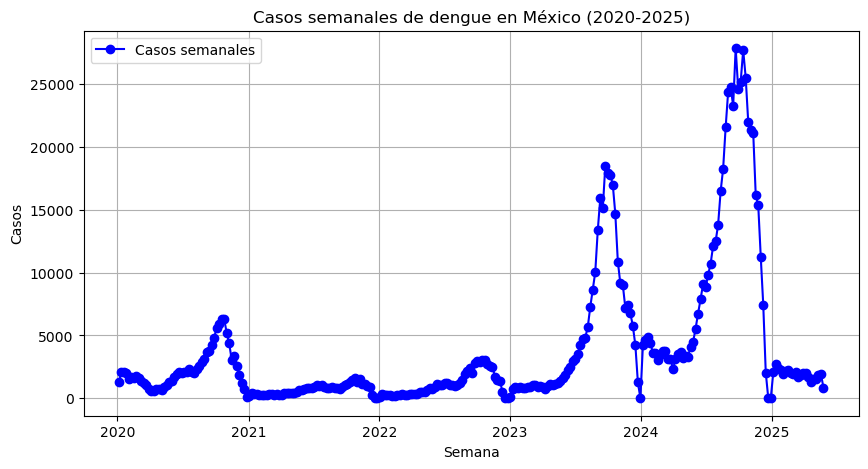

In [91]:
plt.figure(figsize=(10, 5))

plt.plot(
    casos_totales["FECHA"],
    casos_totales["CASOS_NACIONALES"],
    marker="o",
    label="Casos semanales",
    color="blue"
)

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Casos semanales de dengue en México (2020-2025)")
plt.legend()
plt.grid()

plt.show()

**Interpretación de la serie de casos de dengue en México**

Se observa que los casos de dengue presentan picos importantes a mediados de 2020, a finales de 2023 y a finales de 2024. El número máximo de casos aumenta de 2020 a 2023, y el pico más alto se alcanza en 2024. La serie tiene un comportamiento variable, ya que no se estabiliza alrededor de un valor fijo. De forma aproximada, se puede observar que hacia finales de cada año tienden a presentarse aumentos en los casos.

El modelo puede tener dificultades para predecir correctamente los casos de dengue porque la serie presenta comportamientos diferentes entre años y picos abruptos. Además, solo se está usando información histórica de casos, pero no se incluyen otras variables que podrían ser importantes. Por ejemplo, el dengue se transmite por mosquitos, y estos pueden reproducirse más en temporadas de lluvia por la acumulación de agua estancada. Por eso, variables como la precipitación, temperatura o humedad podrían mejorar la predicción. Al no contar con esa información, el modelo puede tener limitaciones para predecir con alta fidelidad los cambios fuertes en la serie.

## 3. Construcción de variables temporales

En esta sección se construyen variables predictoras a partir de la serie nacional de casos semanales de dengue. La idea es usar únicamente información disponible hasta la semana (t), con el objetivo de predecir el número de casos de la semana siguiente.

Se consideran las siguientes variables:

* $C_t$: casos nacionales de dengue en la semana actual.
* $C_{t-1}$: casos nacionales de dengue observados una semana antes.
* $C_{t-2}$: casos nacionales de dengue observados dos semanas antes.
* $C_{t-3}$: casos nacionales de dengue observados tres semanas antes.
* $C_{t-4}$: casos nacionales de dengue observados cuatro semanas antes.
* $MA_3$: promedio móvil de los casos en las últimas tres semanas.
* $MA_5$: promedio móvil de los casos en las últimas cinco semanas.
* $\Delta C_t$: cambio semanal en el número de casos.

El cambio semanal se define como:

$$
\Delta C_t = C_t - C_{t-1}.
$$

Finalmente, se construye la variable objetivo:

$
C_{t+1},
$

la cual representa los casos nacionales de dengue en la siguiente semana. Esta variable será la que se buscará predecir mediante los modelos de regresión.



## Cambio semanal de casos

Calculamos el cambio absoluto:

$$
\Delta C_t = C_t - C_{t-1}.
$$

In [92]:
casos_totales["CAMBIO_SEMANAL"] = casos_totales["CASOS_NACIONALES"].diff()

casos_totales[["FECHA", "CASOS_NACIONALES", "CAMBIO_SEMANAL"]].head(10)

,FECHA,CASOS_NACIONALES,CAMBIO_SEMANAL
0,2020-01-05,1318,NaN
1,2020-01-12,2068,750.0
2,2020-01-19,2078,10.0
3,2020-01-26,1973,-105.0
4,2020-02-02,1562,-411.0
5,2020-02-09,1659,97.0
6,2020-02-16,1593,-66.0
7,2020-02-23,1756,163.0
8,2020-03-01,1598,-158.0
9,2020-03-08,1384,-214.0


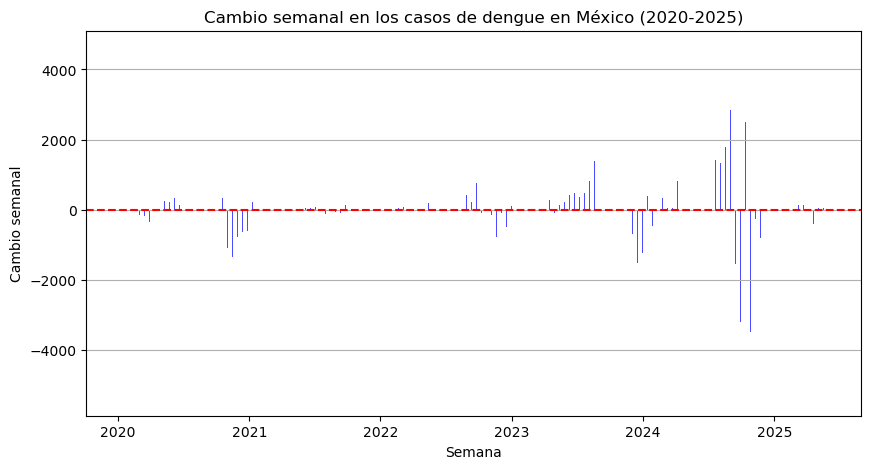

In [93]:
plt.figure(figsize=(10, 5))

plt.axhline(y=0, linestyle="--",color='red')
plt.bar(casos_totales["FECHA"], casos_totales["CAMBIO_SEMANAL"], color='blue',alpha=0.7)

plt.xlabel("Semana")
plt.ylabel("Cambio semanal")
plt.title("Cambio semanal en los casos de dengue en México (2020-2025)")
plt.grid(axis="y")

plt.show()

Se puede observar que el cambio semanal es mucho mayor en 2024 en comparación a los otros años. También en el 2024 se muestra tanto el mayor aumento como la mayor disminución de casos.

# Promedio móvil

Se calcula el promedio movil para una ventana de 3 semanas:

$$
MA_t = \frac{C_t + C_{t-1} + C_{t-2}}{3}.
$$

Igualmente se calcula el promedio movil para una ventana de 5 semanas:

$$
MA_t = \frac{C_t + C_{t-1} + C_{t-2} + C_{t-3} + C_{t-4} }{5}.
$$


In [94]:
casos_totales["promedio_movil_3"] = casos_totales["CASOS_NACIONALES"].rolling(window=3).mean()
casos_totales["promedio_movil_5"] = casos_totales["CASOS_NACIONALES"].rolling(window=5).mean()

casos_totales[["FECHA", "CASOS_NACIONALES", "promedio_movil_3", "promedio_movil_5"]].head(10)

,FECHA,CASOS_NACIONALES,promedio_movil_3,promedio_movil_5
0,2020-01-05,1318,NaN,NaN
1,2020-01-12,2068,NaN,NaN
2,2020-01-19,2078,1821.333333,NaN
3,2020-01-26,1973,2039.666667,NaN
4,2020-02-02,1562,1871.000000,1799.8
5,2020-02-09,1659,1731.333333,1868.0
6,2020-02-16,1593,1604.666667,1773.0
7,2020-02-23,1756,1669.333333,1708.6
8,2020-03-01,1598,1649.000000,1633.6
9,2020-03-08,1384,1579.333333,1598.0


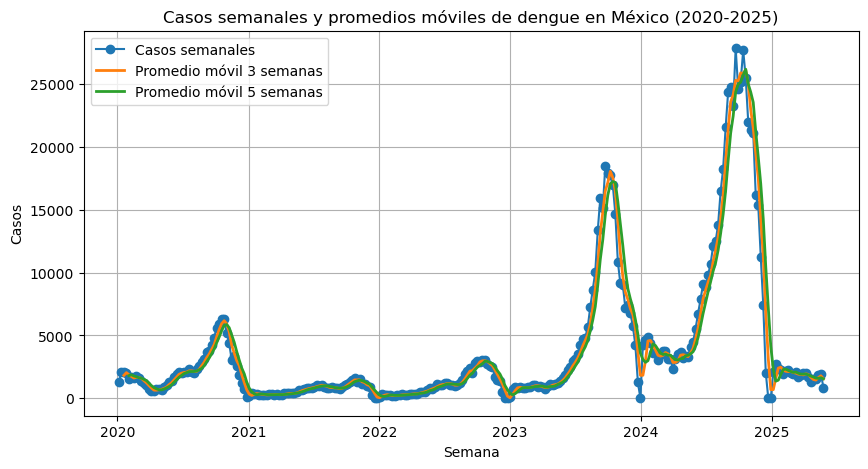

In [95]:
plt.figure(figsize=(10, 5))

plt.plot(
    casos_totales["FECHA"],
    casos_totales["CASOS_NACIONALES"],
    marker="o",
    label="Casos semanales"
)

plt.plot(
    casos_totales["FECHA"],
    casos_totales["promedio_movil_3"],
    linewidth=2,
    label="Promedio móvil 3 semanas"
)

plt.plot(
    casos_totales["FECHA"],
    casos_totales["promedio_movil_5"],
    linewidth=2,
    label="Promedio móvil 5 semanas"
)

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Casos semanales y promedios móviles de dengue en México (2020-2025)")
plt.legend()
plt.grid()

plt.show()

## Rezagos temporales

Se calculan los rezagos temporales para los casos totales de dengue.

$$
C_{t-1}, \quad C_{t-2}, \quad C_{t-3}, \quad C_{t-4}
$$

In [96]:
casos_totales["lag_1"] = casos_totales["CASOS_NACIONALES"].shift(1)
casos_totales["lag_2"] = casos_totales["CASOS_NACIONALES"].shift(2)
casos_totales["lag_3"] = casos_totales["CASOS_NACIONALES"].shift(3)
casos_totales["lag_4"] = casos_totales["CASOS_NACIONALES"].shift(4)

casos_totales[["FECHA", "CASOS_NACIONALES", "lag_1", "lag_2", "lag_3", "lag_4"]].head(10)

,FECHA,CASOS_NACIONALES,lag_1,lag_2,lag_3,lag_4
0,2020-01-05,1318,NaN,NaN,NaN,NaN
1,2020-01-12,2068,1318.0,NaN,NaN,NaN
2,2020-01-19,2078,2068.0,1318.0,NaN,NaN
3,2020-01-26,1973,2078.0,2068.0,1318.0,NaN
4,2020-02-02,1562,1973.0,2078.0,2068.0,1318.0
5,2020-02-09,1659,1562.0,1973.0,2078.0,2068.0
6,2020-02-16,1593,1659.0,1562.0,1973.0,2078.0
7,2020-02-23,1756,1593.0,1659.0,1562.0,1973.0
8,2020-03-01,1598,1756.0,1593.0,1659.0,1562.0
9,2020-03-08,1384,1598.0,1756.0,1593.0,1659.0


In [97]:
casos_totales.head()

,FECHA,CASOS_NACIONALES,CAMBIO_SEMANAL,promedio_movil_3,promedio_movil_5,lag_1,lag_2,lag_3,lag_4
0,2020-01-05,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-12,2068,750.0,NaN,NaN,1318.0,NaN,NaN,NaN
2,2020-01-19,2078,10.0,1821.333333,NaN,2068.0,1318.0,NaN,NaN
3,2020-01-26,1973,-105.0,2039.666667,NaN,2078.0,2068.0,1318.0,NaN
4,2020-02-02,1562,-411.0,1871.000000,1799.8,1973.0,2078.0,2068.0,1318.0


# Variable objetivo para predicción

Construimos una variable de casos de la siguiente semana como objetivo para la predicción.

$$
C_{t+1}.
$$

In [98]:

casos_totales["casos_siguiente_semana"] = casos_totales["CASOS_NACIONALES"].shift(-1)
df_modelo = casos_totales[[
    "FECHA",
    "CASOS_NACIONALES",
    "CAMBIO_SEMANAL",
    "promedio_movil_3",
    "promedio_movil_5",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "casos_siguiente_semana"
]].copy()

df_modelo.head(10)

,FECHA,CASOS_NACIONALES,CAMBIO_SEMANAL,promedio_movil_3,promedio_movil_5,lag_1,lag_2,lag_3,lag_4,casos_siguiente_semana
0,2020-01-05,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2068.0
1,2020-01-12,2068,750.0,NaN,NaN,1318.0,NaN,NaN,NaN,2078.0
2,2020-01-19,2078,10.0,1821.333333,NaN,2068.0,1318.0,NaN,NaN,1973.0
3,2020-01-26,1973,-105.0,2039.666667,NaN,2078.0,2068.0,1318.0,NaN,1562.0
4,2020-02-02,1562,-411.0,1871.000000,1799.8,1973.0,2078.0,2068.0,1318.0,1659.0
5,2020-02-09,1659,97.0,1731.333333,1868.0,1562.0,1973.0,2078.0,2068.0,1593.0
6,2020-02-16,1593,-66.0,1604.666667,1773.0,1659.0,1562.0,1973.0,2078.0,1756.0
7,2020-02-23,1756,163.0,1669.333333,1708.6,1593.0,1659.0,1562.0,1973.0,1598.0
8,2020-03-01,1598,-158.0,1649.000000,1633.6,1756.0,1593.0,1659.0,1562.0,1384.0
9,2020-03-08,1384,-214.0,1579.333333,1598.0,1598.0,1756.0,1593.0,1659.0,1200.0


Eliminamos las filas con valores faltantes debido a los rezagos y promedios móviles

In [99]:
df_modelo = df_modelo.dropna().reset_index(drop=True)
df_modelo.head()

,FECHA,CASOS_NACIONALES,CAMBIO_SEMANAL,promedio_movil_3,promedio_movil_5,lag_1,lag_2,lag_3,lag_4,casos_siguiente_semana
0,2020-02-02,1562,-411.0,1871.000000,1799.8,1973.0,2078.0,2068.0,1318.0,1659.0
1,2020-02-09,1659,97.0,1731.333333,1868.0,1562.0,1973.0,2078.0,2068.0,1593.0
2,2020-02-16,1593,-66.0,1604.666667,1773.0,1659.0,1562.0,1973.0,2078.0,1756.0
3,2020-02-23,1756,163.0,1669.333333,1708.6,1593.0,1659.0,1562.0,1973.0,1598.0
4,2020-03-01,1598,-158.0,1649.000000,1633.6,1756.0,1593.0,1659.0,1562.0,1384.0


## Interpretación de la tabla preparada

El dataframe construido ya tiene la estructura necesaria para ser usado en un modelo predictivo. Cada fila representa una semana y contiene información histórica disponible hasta la semana actual $t$.

Las variables predictoras que se utilizarán son:

* $C_t$: casos nacionales de dengue en la semana actual.
* $C_{t-1}$: casos nacionales de dengue observados una semana antes.
* $C_{t-2}$: casos nacionales de dengue observados dos semanas antes.
* $C_{t-3}$: casos nacionales de dengue observados tres semanas antes.
* $C_{t-4}$: casos nacionales de dengue observados cuatro semanas antes.
* $MA_3$: promedio móvil de los casos en las últimas tres semanas.
* $MA_5$: promedio móvil de los casos en las últimas cinco semanas.
* $\Delta C_t$: cambio semanal en el número de casos.

$$
X = {C_t, C_{t-1}, C_{t-2}, C_{t-3}, C_{t-4}, MA_3, MA_5, \Delta C_t}.
$$

La variable objetivo será:

$$
y = C_{t+1}.
$$

El objetivo del modelo es predecir los casos nacionales de dengue de la semana siguiente usando la información disponible hasta la semana actual.


In [100]:
X = df_modelo[[
    "CASOS_NACIONALES", "CAMBIO_SEMANAL", "promedio_movil_3", "promedio_movil_5", "lag_1", "lag_2", "lag_3", "lag_4"]]

y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   CASOS_NACIONALES  CAMBIO_SEMANAL  promedio_movil_3  promedio_movil_5  \
0              1562          -411.0       1871.000000            1799.8   
1              1659            97.0       1731.333333            1868.0   
2              1593           -66.0       1604.666667            1773.0   
3              1756           163.0       1669.333333            1708.6   
4              1598          -158.0       1649.000000            1633.6   

    lag_1   lag_2   lag_3   lag_4  
0  1973.0  2078.0  2068.0  1318.0  
1  1562.0  1973.0  2078.0  2068.0  
2  1659.0  1562.0  1973.0  2078.0  
3  1593.0  1659.0  1562.0  1973.0  
4  1756.0  1593.0  1659.0  1562.0  
0    1659.0
1    1593.0
2    1756.0
3    1598.0
4    1384.0
Name: casos_siguiente_semana, dtype: float64


## 4. Modelos de regresión


In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

Se dividen los datos en conjunto de entrenamiento y conjunto de prueba respetando el orden temporal.

In [102]:
n = len(X)
print("Número total de semanas en el modelo:", n)
corte = int(n * 0.7)

X_train = X.iloc[:corte].copy()
X_test  = X.iloc[corte:].copy()

y_train = y.iloc[:corte].copy()
y_test  = y.iloc[corte:].copy()

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)


Número total de semanas en el modelo: 277
Tamaño X_train: (193, 8)
Tamaño X_test: (84, 8)
Tamaño y_train: (193,)
Tamaño y_test: (84,)


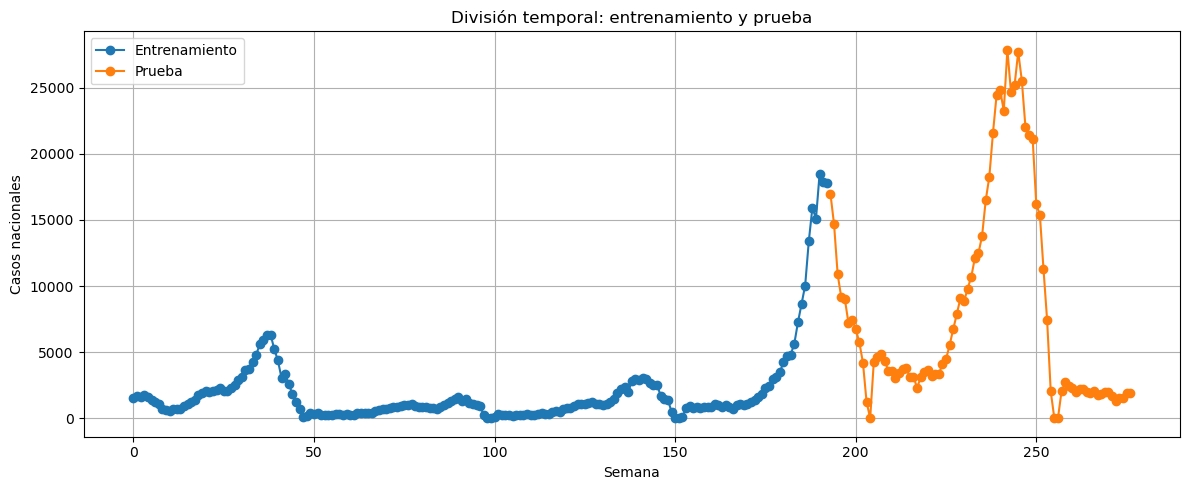

In [103]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(X_train)),
    X_train["CASOS_NACIONALES"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    range(len(X_train), len(X_train) + len(X_test)),
    X_test["CASOS_NACIONALES"],
    marker="o",
    label="Prueba"
)


plt.xlabel("Semana")
plt.ylabel("Casos nacionales")
plt.title("División temporal: entrenamiento y prueba")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Se comparan los siguientes modelos:

1. Modelo ingenuo.
2. Regresión lineal.
3. Árbol de decisión.
4. Random Forest.

El modelo ingenuo usa la regla:

$$
\widehat{C}_{t+1}=C_t.
$$

Predice que la siguiente semana tendrá el mismo número de casos que la semana actual.

In [104]:
pred_naive = y.shift(1).iloc[corte:]

mae_naive = mean_absolute_error(y_test, pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, pred_naive))

print("Modelo ingenuo")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

Modelo ingenuo
MAE: 1163.3690476190477
RMSE: 1751.9682434880137


In [105]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Regresión lineal")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Regresión lineal
MAE: 1166.2225149227538
RMSE: 1682.1244938533534


In [106]:
modelo_arbol = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

mae_arbol = mean_absolute_error(y_test, pred_arbol)
rmse_arbol = np.sqrt(mean_squared_error(y_test, pred_arbol))

print("Árbol de decisión")
print("MAE:", mae_arbol)
print("RMSE:", rmse_arbol)

Árbol de decisión
MAE: 2620.7444064148785
RMSE: 4091.9078101873097


In [107]:
from sklearn.ensemble import RandomForestRegressor

In [108]:
modelo_rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    random_state=42
)

modelo_rf_base.fit(X_train, y_train)

pred_rf_base = modelo_rf_base.predict(X_test)

mae_rf_base = mean_absolute_error(y_test, pred_rf_base)
rmse_rf_base = np.sqrt(mean_squared_error(y_test, pred_rf_base))

print("Random Forest base")
print("MAE:", mae_rf_base)
print("RMSE:", rmse_rf_base)

Random Forest base
MAE: 2590.8775918951787
RMSE: 4018.476566607355


## Efecto del número de árboles

Se muestra cómo cambia el desempeño del Random Forest al modificar `n_estimators`.

In [109]:
n_arboles = [3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20]

resultados_rf = []

for n_est in n_arboles:
    modelo_temp = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=4,
        random_state=42
    )
    
    modelo_temp.fit(X_train, y_train)
    pred_temp = modelo_temp.predict(X_test)
    
    mae_temp =  mean_absolute_error(y_test, pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test, pred_temp))

    
    resultados_rf.append({
        "n_estimators": n_est,
        "MAE": mae_temp,
        "RMSE": rmse_temp
    })

df_resultados_rf = pd.DataFrame(resultados_rf)

df_resultados_rf

,n_estimators,MAE,RMSE
0,3,2419.904326,3818.204072
1,4,2413.894217,3817.729005
2,5,2379.777739,3737.637630
3,6,2414.333827,3797.351550
4,7,2403.197069,3773.275862
5,8,2362.739874,3761.006027
6,9,2396.441180,3813.231861
7,10,2387.075269,3794.127540
8,12,2463.943908,3888.030810
9,14,2477.027112,3929.561451


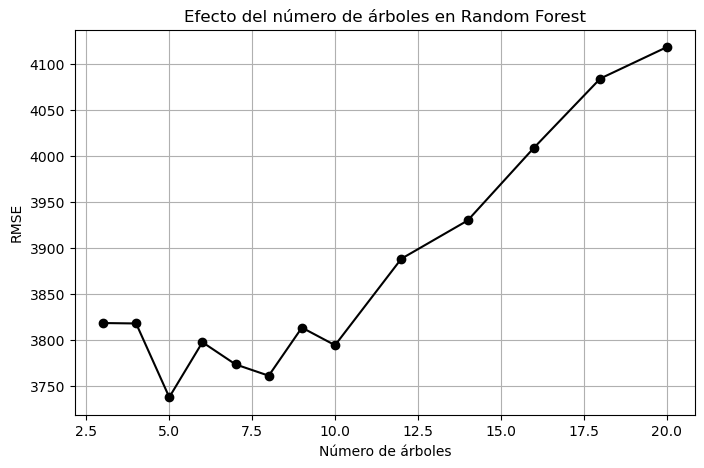

In [110]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_rf["n_estimators"],
    df_resultados_rf["RMSE"],
    marker="o", color='black'
)

plt.xlabel("Número de árboles")
plt.ylabel("RMSE")
plt.title("Efecto del número de árboles en Random Forest")
plt.grid()

plt.show()

### Efecto de `número de árboles` en Random Forest
En la gráfica se observa que el menor RMSE se obtiene con 5 árboles, por lo que en este caso fue el mejor valor probado. Al aumentar el número de árboles, el error no disminuye; al contrario, después de cierto punto empieza a subir. Por eso, para estos datos y esta división de entrenamiento/prueba, usar más árboles no mejoró el modelo. En este experimento conviene quedarse con 5 árboles.

## Efecto de la profundidad en Random Forest

In [111]:
profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]

resultados_depth = []

for d in profundidades:
    modelo_temp = RandomForestRegressor(
        n_estimators=50,
        max_depth=d,
        random_state=42
    )
    
    modelo_temp.fit(X_train, y_train)
    pred_temp = modelo_temp.predict(X_test)

    mae_temp =  mean_absolute_error(y_test, pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test, pred_temp))

    resultados_depth.append({
        "max_depth": d,
        "MAE": mae_temp,
        "RMSE": rmse_temp
    })

df_resultados_depth = pd.DataFrame(resultados_depth)

df_resultados_depth

,max_depth,MAE,RMSE
0,1,3231.369156,4536.493287
1,2,2651.627696,4001.080705
2,3,2552.351594,3984.017856
3,4,2582.230581,4047.376347
4,5,2668.264431,4169.086666
5,6,2598.178618,4068.097585
6,7,2618.652568,4070.637308
7,8,2551.808084,4003.121957
8,9,2566.156969,4028.189059
9,10,2542.982157,3974.493192


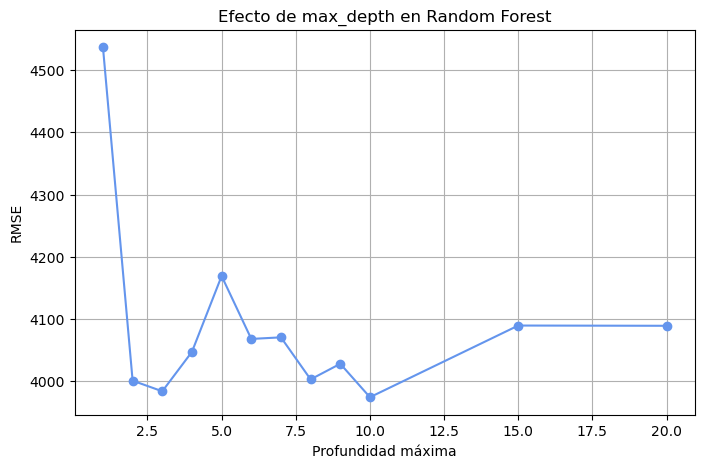

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_depth["max_depth"],
    df_resultados_depth["RMSE"],
    marker="o", color='cornflowerblue'
)

plt.xlabel("Profundidad máxima")
plt.ylabel("RMSE")
plt.title("Efecto de max_depth en Random Forest")
plt.grid()

plt.show()

### Efecto de `max_depth` en Random Forest
En esta gráfica se ve que la profundidad máxima sí afecta el error. Con profundidad 1 el RMSE es muy alto, por lo que el modelo queda demasiado simple. El mejor resultado aparece alrededor de max_depth = 10, donde el error es menor. Después de ese punto, aumentar la profundidad ya no mejora mucho el desempeño y el RMSE se mantiene parecido. Por eso, para este experimento conviene usar una profundidad cercana a 10.

## Búsqueda combinada sencilla
Realizamos una búsqueda pequeña de combinaciones:

In [113]:
valores_arboles = [3, 5, 8, 10, 15, 20]
profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]

resultados_grid = []

for n_est in valores_arboles:
    for d in profundidades:
        
        modelo_temp = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=d,
            random_state=42
        )
        
        modelo_temp.fit(X_train, y_train)
        pred_temp = modelo_temp.predict(X_test)

        mae_temp = mean_absolute_error(y_test, pred_temp)
        rmse_temp = np.sqrt(mean_squared_error(y_test, pred_temp))

        resultados_grid.append({
            "n_estimators": n_est,
            "max_depth": d,
            "MAE": mae_temp,
            "RMSE": rmse_temp
        })

df_grid = pd.DataFrame(resultados_grid)

df_grid.sort_values("RMSE").head(10)

,n_estimators,max_depth,MAE,RMSE
7,3,8,2292.273306,3709.780892
31,8,8,2344.333996,3710.981476
15,5,4,2379.777739,3737.637630
27,8,4,2362.739874,3761.006027
43,10,8,2388.942494,3775.306836
39,10,4,2387.075269,3794.127540
3,3,4,2419.904326,3818.204072
14,5,3,2487.406607,3858.805259
19,5,8,2419.060544,3872.043176
17,5,6,2417.687313,3894.478651


In [114]:
mejor_rf = df_grid.sort_values("RMSE").iloc[0]
mejor_rf

n_estimators       3.000000
max_depth          8.000000
MAE             2292.273306
RMSE            3709.780892
Name: 7, dtype: float64

In [115]:
modelo_rf_opt = RandomForestRegressor(
    n_estimators=int(mejor_rf["n_estimators"]),
    max_depth=int(mejor_rf["max_depth"]),
    random_state=42
)

modelo_rf_opt.fit(X_train, y_train)

pred_rf_opt = modelo_rf_opt.predict(X_test)

mae_rf_opt = mean_absolute_error(y_test, pred_rf_opt)
rmse_rf_opt = np.sqrt(mean_squared_error(y_test, pred_rf_opt))

print("Random Forest optimizado")
print("n_estimators:", int(mejor_rf["n_estimators"]))
print("max_depth:", int(mejor_rf["max_depth"]))
print("MAE:", mae_rf_opt)
print("RMSE:", rmse_rf_opt)

Random Forest optimizado
n_estimators: 3
max_depth: 8
MAE: 2292.273305618544
RMSE: 3709.7808916095373


## 5. Comparación de modelos de regresión


### Tabla comparativa de modelos

In [116]:
df_metricas_final = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Árbol de decisión",
        "Random Forest inicial",
        "Random Forest optimizado"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_arbol,
        mae_rf_base,
        mae_rf_opt
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_arbol,
        rmse_rf_base,
        rmse_rf_opt
    ]
})

df_metricas_final = df_metricas_final.sort_values("RMSE")

df_metricas_final

,modelo,MAE,RMSE
1,Regresión lineal,1166.222515,1682.124494
0,Naive,1163.369048,1751.968243
4,Random Forest optimizado,2292.273306,3709.780892
3,Random Forest inicial,2590.877592,4018.476567
2,Árbol de decisión,2620.744406,4091.907810


### Gráfica: casos observados vs modelos

In [117]:
df_predicciones = pd.DataFrame({
    "Observado": y_test,
    "Modelo ingenuo": pred_naive,
    "Regresión lineal": pd.Series(pred_lr, index=y_test.index),
    "Árbol de decisión": pd.Series(pred_arbol, index=y_test.index),
    "Random Forest inicial": pd.Series(pred_rf_base, index=y_test.index),
    "Random Forest optimizado": pd.Series(pred_rf_opt, index=y_test.index)
})

df_predicciones.head()

,Observado,Modelo ingenuo,Regresión lineal,Árbol de decisión,Random Forest inicial,Random Forest optimizado
193,14673.0,16980.0,15781.281055,17795.25,17427.327992,17524.000000
194,10886.0,14673.0,13113.674815,17795.25,17425.264659,17758.666667
195,9136.0,10886.0,8363.258303,17795.25,16946.880052,15446.000000
196,8996.0,9136.0,5817.734133,15514.50,16061.302690,14821.333333
197,7181.0,8996.0,6246.247842,15514.50,15179.754663,11540.000000


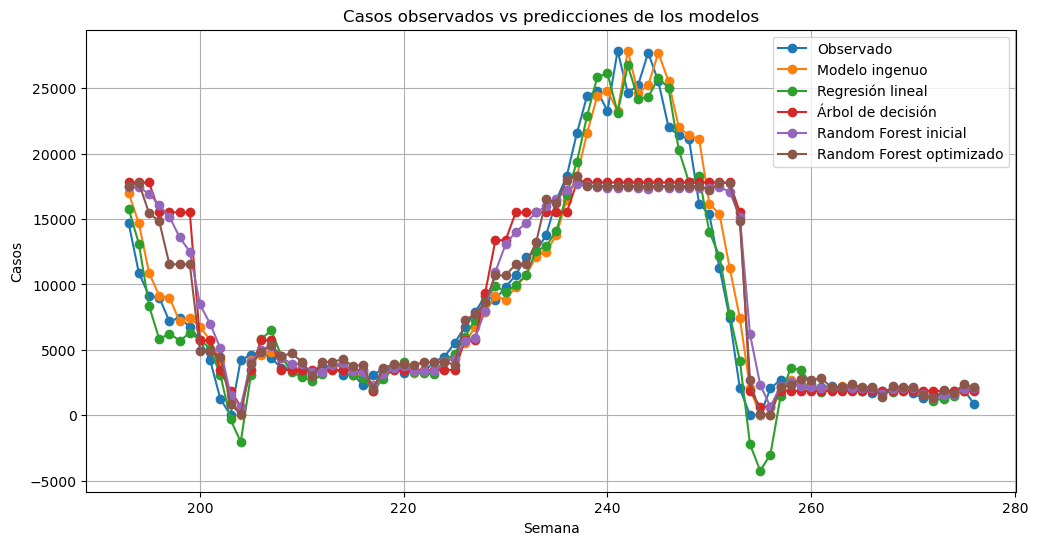

In [118]:
plt.figure(figsize=(12, 6))

plt.plot(df_predicciones.index, df_predicciones["Observado"], marker="o", label="Observado")
plt.plot(df_predicciones.index, df_predicciones["Modelo ingenuo"], marker="o", label="Modelo ingenuo")
plt.plot(df_predicciones.index, df_predicciones["Regresión lineal"], marker="o", label="Regresión lineal")
plt.plot(df_predicciones.index, df_predicciones["Árbol de decisión"], marker="o", label="Árbol de decisión")
plt.plot(df_predicciones.index, df_predicciones["Random Forest inicial"], marker="o", label="Random Forest inicial")
plt.plot(df_predicciones.index, df_predicciones["Random Forest optimizado"], marker="o", label="Random Forest optimizado")

plt.xlabel("Semana")
plt.ylabel("Casos")
plt.title("Casos observados vs predicciones de los modelos")
plt.legend()
plt.grid()

plt.show()

Se evaluan los modelos usando $MAE$ y $RMSE$. Se reporta una tabla comparativa de modelos y una gráfica comparando los casos observados contra las predicciones de al menos dos modelos, incluyendo el modelo ingenuo y el mejor modelo obtenido.
### Interpretación de la gráfica
¿Qué modelo tuvo menor MAE?
Modelo ingenuo.

¿Qué modelo tuvo menor RMSE?
Regresión lineal.

¿El modelo más complejo fue necesariamente el mejor?
No. El modelo más complejo no fue necesariamente el mejor. Aunque Random Forest es un modelo más avanzado que la regresión lineal o el modelo ingenuo, en este caso obtuvo errores más altos. Esto indica que aumentar la complejidad del modelo no siempre mejora las predicciones. Para estos datos, los modelos más simples lograron ajustarse mejor al comportamiento observado.


¿Algún modelo logró mejorar al modelo ingenuo?
Sí, la regresión lineal mejoró al modelo ingenuo en RMSE, aunque no superó al modelo ingenuo en MAE.

¿Qué modelo parece capturar mejor los picos?
La regresión lineal y el modelo ingenuo. Random Forest no capturó bien los picos altos.

¿En qué periodos se observan los mayores errores?
En los cambios bruscos cerca de los picos máximos y en las caídas rápidas posteriores.



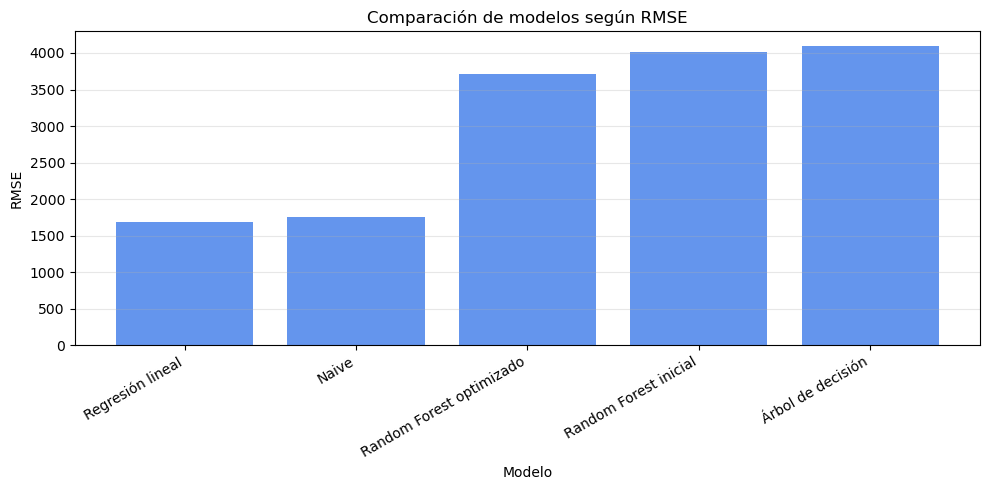

In [119]:
df_metricas_plot = df_metricas_final.sort_values("RMSE")

plt.figure(figsize=(10, 5))

plt.bar(
    df_metricas_plot["modelo"],
    df_metricas_plot["RMSE"],
    color="cornflowerblue"
)

plt.ylabel("RMSE")
plt.xlabel("Modelo")
plt.title("Comparación de modelos según RMSE")
plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

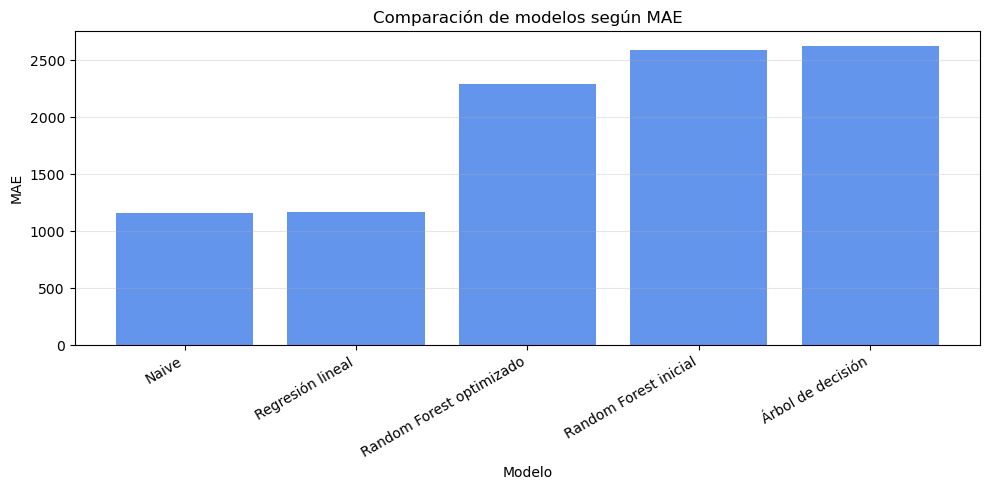

In [120]:
df_metricas_plot = df_metricas_final.sort_values("MAE")

plt.figure(figsize=(10, 5))

plt.bar(
    df_metricas_plot["modelo"],
    df_metricas_plot["MAE"],
    color="cornflowerblue"
)

plt.ylabel("MAE")
plt.xlabel("Modelo")
plt.title("Comparación de modelos según MAE")
plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Interpretación de las gráficas de barras de los errores MAE y RMSE

En las gráficas se observa que los modelos con menor error fueron el modelo ingenuo y la regresión lineal. El modelo ingenuo tuvo el menor MAE, por lo que en promedio se equivocó menos. En cambio, la regresión lineal tuvo el menor RMSE, lo que indica que manejó mejor los errores grandes.

Los modelos más complejos, como Random Forest y el árbol de decisión, no fueron necesariamente mejores, ya que obtuvieron errores más altos. Por lo tanto, para estos datos, los modelos simples dieron mejores resultados.

## 6. Clasificación de semanas de riesgo


Se clasifica la siguiente semana como:

$$
\text{riesgo bajo}, \quad \text{riesgo medio}, \quad \text{riesgo alto}.
$$

Para construir estas categorías, se usan cuantiles de la variable $C_{t+1}$, de forma que las tres clases tengan tamaños aproximadamente similares.


In [121]:
df_modelo["riesgo_actual"], cortes = pd.qcut(
    df_modelo["CASOS_NACIONALES"],
    q=3,
    labels=["bajo", "medio", "alto"],
    retbins=True # esta linea de codigo hace que se devuelvan los cortes utilizados para definir las categorías, 
    # lo cual es útil para entender cómo se clasificaron los casos en bajo, medio y alto riesgo.
)
df_modelo

,FECHA,CASOS_NACIONALES,CAMBIO_SEMANAL,promedio_movil_3,promedio_movil_5,lag_1,lag_2,lag_3,lag_4,casos_siguiente_semana,riesgo_actual
0,2020-02-02,1562,-411.0,1871.000000,1799.8,1973.0,2078.0,2068.0,1318.0,1659.0,medio
1,2020-02-09,1659,97.0,1731.333333,1868.0,1562.0,1973.0,2078.0,2068.0,1593.0,medio
2,2020-02-16,1593,-66.0,1604.666667,1773.0,1659.0,1562.0,1973.0,2078.0,1756.0,medio
3,2020-02-23,1756,163.0,1669.333333,1708.6,1593.0,1659.0,1562.0,1973.0,1598.0,medio
4,2020-03-01,1598,-158.0,1649.000000,1633.6,1756.0,1593.0,1659.0,1562.0,1384.0,medio
...,...,...,...,...,...,...,...,...,...,...,...
272,2025-04-20,1280,-413.0,1654.333333,1762.8,1693.0,1990.0,1977.0,1874.0,1504.0,medio
273,2025-04-27,1504,224.0,1492.333333,1688.8,1280.0,1693.0,1990.0,1977.0,1549.0,medio
274,2025-05-04,1549,45.0,1444.333333,1603.2,1504.0,1280.0,1693.0,1990.0,1878.0,medio
275,2025-05-11,1878,329.0,1643.666667,1580.8,1549.0,1504.0,1280.0,1693.0,1932.0,medio


Se reportan los cortes utilizados para definir las categorías.

In [122]:
df_cortes = pd.DataFrame({
    "categoria": ["bajo", "medio", "alto"],
    "desde": [cortes[0], cortes[1], cortes[2]],
    "hasta": [cortes[1], cortes[2], cortes[3]]
})

df_cortes

,categoria,desde,hasta
0,bajo,0.0,992.0
1,medio,992.0,2785.0
2,alto,2785.0,27869.0


In [123]:
df_modelo["riesgo_siguiente_semana"] = df_modelo["riesgo_actual"].shift(-1)
df_modelo = df_modelo.dropna().reset_index(drop=True)
df_modelo.isna().sum()

FECHA                      0
CASOS_NACIONALES           0
CAMBIO_SEMANAL             0
promedio_movil_3           0
promedio_movil_5           0
lag_1                      0
lag_2                      0
lag_3                      0
lag_4                      0
casos_siguiente_semana     0
riesgo_actual              0
riesgo_siguiente_semana    0
dtype: int64

Se reporta cuántas semanas quedaron en cada categoría.

In [124]:
# Revisar conteo antes del ajuste
conteo_riesgo = df_modelo["riesgo_actual"].value_counts().reindex(["bajo", "medio", "alto"])
print("Antes del ajuste:")
print(conteo_riesgo)

Antes del ajuste:
riesgo_actual
bajo     93
medio    91
alto     92
Name: count, dtype: int64


In [125]:
# Buscar el caso clasificado como bajo que está más cerca de medio
idx_ajuste = df_modelo.loc[
    df_modelo["riesgo_actual"] == "bajo",
    "CASOS_NACIONALES"
].idxmax()

print("Índice ajustado:", idx_ajuste)
print(df_modelo.loc[idx_ajuste, ["FECHA", "CASOS_NACIONALES", "riesgo_actual"]])

# Cambiar manualmente de bajo a medio
df_modelo.loc[idx_ajuste, "riesgo_actual"] = "medio"

Índice ajustado: 95
FECHA               2021-11-28 00:00:00
CASOS_NACIONALES                    992
riesgo_actual                      bajo
Name: 95, dtype: object


In [126]:
conteo_riesgo = df_modelo["riesgo_actual"].value_counts().reindex(["bajo", "medio", "alto"])

print("Después del ajuste:")
print(conteo_riesgo)

Después del ajuste:
riesgo_actual
bajo     92
medio    92
alto     92
Name: count, dtype: int64


In [127]:
if idx_ajuste > 0:
    df_modelo.loc[idx_ajuste - 1, "riesgo_siguiente_semana"] = "medio"

In [128]:
df_modelo.loc[
    idx_ajuste-2:idx_ajuste+2,
    ["FECHA", "CASOS_NACIONALES", "riesgo_actual", "riesgo_siguiente_semana"]
]

,FECHA,CASOS_NACIONALES,riesgo_actual,riesgo_siguiente_semana
93,2021-11-14,1120,medio,medio
94,2021-11-21,1105,medio,medio
95,2021-11-28,992,medio,bajo
96,2021-12-05,895,bajo,bajo
97,2021-12-12,260,bajo,bajo


Cada categoría tiene 92 semanas.

## 7. Modelos de clasificación


Para la clasificación de riesgo se usan las mismas variables predictoras construidas previamente.


In [129]:
X_clf = df_modelo[[
    "CASOS_NACIONALES",
    "CAMBIO_SEMANAL",
    "promedio_movil_3",
    "promedio_movil_5",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4"
]].copy()
y_clf = df_modelo["riesgo_siguiente_semana"].copy() 
print("Valores faltantes en X_clf:")
print(X_clf.isna().sum())
print("Valores faltantes en y_clf:")
print(y_clf.isna().sum())
print("Dimensiones de X_clf:")
print(X_clf.shape)
print("Dimensiones de y_clf:")
print(y_clf.shape)

Valores faltantes en X_clf:
CASOS_NACIONALES    0
CAMBIO_SEMANAL      0
promedio_movil_3    0
promedio_movil_5    0
lag_1               0
lag_2               0
lag_3               0
lag_4               0
dtype: int64
Valores faltantes en y_clf:
0
Dimensiones de X_clf:
(276, 8)
Dimensiones de y_clf:
(276,)


## División temporal entrenamiento y prueba

Como es una serie temporal, no mezclamos aleatoriamente las semanas.

In [130]:
n = len(X_clf)
n_train = int(0.7 * n)

df_train_clf = df_modelo.iloc[:n_train].copy()
df_test_clf  = df_modelo.iloc[n_train:].copy()

X_train_clf = X_clf.iloc[:n_train].copy()
X_test_clf  = X_clf.iloc[n_train:].copy()

y_train_clf = y_clf.iloc[:n_train].copy()
y_test_clf  = y_clf.iloc[n_train:].copy()

print("Conjunto de entrenamiento:")
print(f"  X_train_clf: {X_train_clf.shape[0]} semanas y {X_train_clf.shape[1]} variables predictoras")
print(f"  y_train_clf: {y_train_clf.shape[0]} categorías de riesgo")

print("Conjunto de prueba:")
print(f"  X_test_clf: {X_test_clf.shape[0]} semanas y {X_test_clf.shape[1]} variables predictoras")
print(f"  y_test_clf: {y_test_clf.shape[0]} categorías de riesgo")

Conjunto de entrenamiento:
  X_train_clf: 193 semanas y 8 variables predictoras
  y_train_clf: 193 categorías de riesgo
Conjunto de prueba:
  X_test_clf: 83 semanas y 8 variables predictoras
  y_test_clf: 83 categorías de riesgo


### Gráfica de clasificación con datos de entrenamiento y prueba

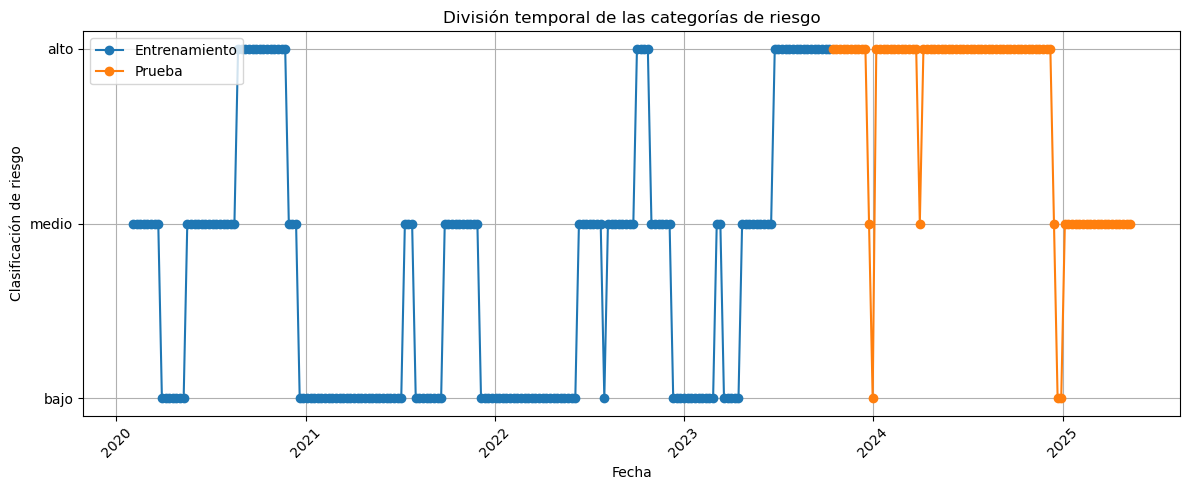

In [131]:
mapa_riesgo = {
    "bajo": 0,
    "medio": 1,
    "alto": 2
}

df_train_clf["riesgo_num"] = df_train_clf["riesgo_actual"].map(mapa_riesgo)
df_test_clf["riesgo_num"] = df_test_clf["riesgo_actual"].map(mapa_riesgo)

plt.figure(figsize=(12, 5))

plt.plot(
    df_train_clf["FECHA"],
    df_train_clf["riesgo_num"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    df_test_clf["FECHA"],
    df_test_clf["riesgo_num"],
    marker="o",
    label="Prueba"
)

plt.yticks([0, 1, 2], ["bajo", "medio", "alto"])

plt.xlabel("Fecha")
plt.ylabel("Clasificación de riesgo")
plt.title("División temporal de las categorías de riesgo")
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretación de la gráfica de clasificación de riesgo

En la gráfica de clasificación de riesgo se observa cómo se distribuyen las categorías bajo, medio y alto a lo largo del tiempo. En el conjunto de entrenamiento aparecen las tres categorías, lo que indica que el modelo tuvo ejemplos de riesgo bajo, medio y alto para aprender.

En el conjunto de prueba se observa que gran parte de las semanas quedaron clasificadas como riesgo alto, especialmente durante 2023 y 2024. Esto muestra que en ese periodo los casos fueron elevados en comparación con los cortes definidos por cuantiles. También se observan algunas caídas puntuales a riesgo medio y bajo, lo que refleja cambios bruscos en el comportamiento de los casos.

La gráfica no se mantiene estable en una sola categoría, sino que presenta transiciones entre niveles de riesgo. Sin embargo, en la parte de prueba predomina claramente el riesgo alto. Esto es importante porque, al tratarse de una serie temporal, la distribución de las categorías en entrenamiento y prueba puede ser diferente. Por esa razón, algunos modelos pueden tener dificultad para clasificar correctamente las semanas si el periodo de prueba tiene un comportamiento distinto al periodo de entrenamiento.

Se comparan los siguientes modelos:

1. Modelo ingenuo de clasificación.
2. Árbol de decisión.
3. Random Forest.

El modelo ingenuo de clasificación debe predecir que la categoría de riesgo de la siguiente semana será igual a la categoría de riesgo de la semana actual.


## Modelo ingenuo para clasificación

El modelo ingenuo dice:

$$
\widehat{Y}_{t+1}=Y_t.
$$

Es decir, predice que el nivel de riesgo de la siguiente semana será igual al nivel de riesgo de la semana actual.

In [132]:

df_test_clf["pred_naive"] = df_test_clf["riesgo_actual"]
acc_naive_clf = accuracy_score(y_test_clf, df_test_clf["pred_naive"])

print("Accuracy modelo ingenuo:", acc_naive_clf)

Accuracy modelo ingenuo: 0.9036144578313253


## Árbol de decisión para clasificación

In [133]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

modelo_arbol.fit(X_train_clf, y_train_clf)

pred_arbol = modelo_arbol.predict(X_test_clf)

acc_arbol_clf = accuracy_score(y_test_clf, pred_arbol)

print("Accuracy árbol de decisión:", acc_arbol_clf)

Accuracy árbol de decisión: 0.9036144578313253


## Random Forest para clasificación

In [134]:
modelo_rf_base = RandomForestClassifier(
    n_estimators=20,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

modelo_rf_base.fit(X_train_clf, y_train_clf)

pred_rf = modelo_rf_base.predict(X_test_clf)

acc_rf_base_clf = accuracy_score(y_test_clf, pred_rf)

print("Accuracy Random Forest (base):", acc_rf_base_clf)

Accuracy Random Forest (base): 0.8795180722891566


## Efecto del número de árboles

Se muestra cómo cambia el desempeño del Random Forest al modificar `n_estimators`.


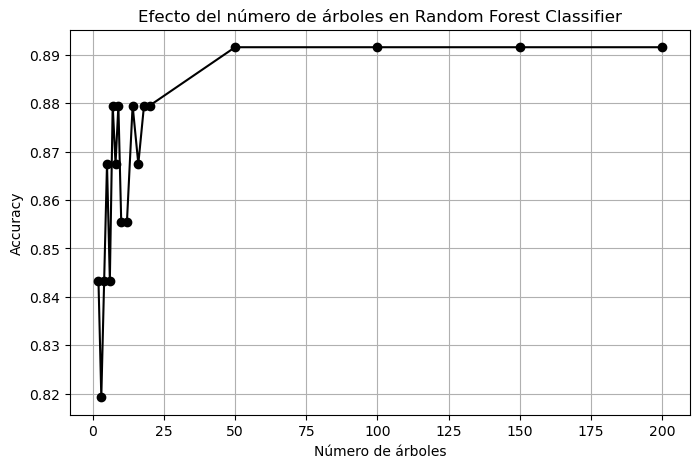

In [135]:
n_arboles_clf = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 50, 100, 150, 200]

resultados_rf_clf = []

for n_est in n_arboles_clf:
    modelo_temp_clf = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=4,
        random_state=42
    )
    
    modelo_temp_clf.fit(X_train_clf, y_train_clf)
    pred_temp_clf = modelo_temp_clf.predict(X_test_clf)
    
    acc_temp_clf = accuracy_score(y_test_clf, pred_temp_clf)
    
    resultados_rf_clf.append({
        "n_estimators": n_est,
        "Accuracy": acc_temp_clf
    })

df_resultados_rf_clf = pd.DataFrame(resultados_rf_clf)

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_rf_clf["n_estimators"],
    df_resultados_rf_clf["Accuracy"],
    marker="o",
    color="black"
)

plt.xlabel("Número de árboles")
plt.ylabel("Accuracy")
plt.title("Efecto del número de árboles en Random Forest Classifier")
plt.grid()

plt.show()

### Interpretación del efecto del número de árboles en la clasificación del Random Forest

Se observa que el accuracy aumenta conforme crece el número de árboles. Con pocos árboles el desempeño es más variable, pero a partir de aproximadamente 100 árboles el accuracy alcanza su valor máximo y se mantiene prácticamente igual hasta 200 árboles. Esto indica que agregar más árboles después de ese punto ya no mejora mucho el modelo. Por lo tanto, para este experimento conviene usar alrededor de 100 árboles.

## Efecto de la profundidad en Random Forest


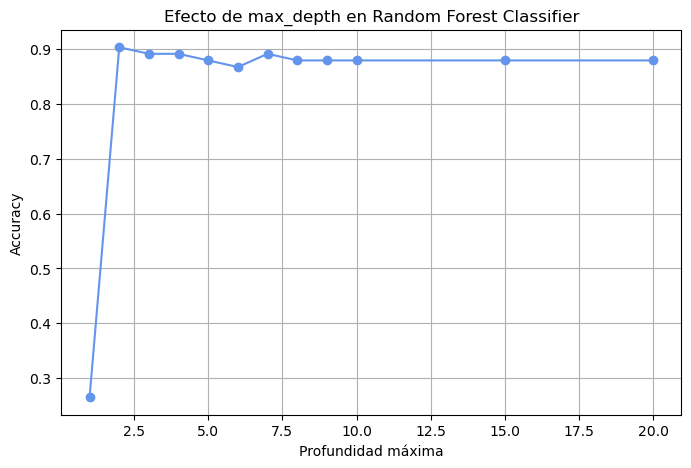

In [136]:
## Efecto de la profundidad en Random Forest Classifier

profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]

resultados_depth_clf = []

for d in profundidades:
    modelo_temp_clf = RandomForestClassifier(
        n_estimators=50,
        max_depth=d,
        random_state=42
    )
    
    modelo_temp_clf.fit(X_train_clf, y_train_clf)
    pred_temp_clf = modelo_temp_clf.predict(X_test_clf)

    acc_temp_clf = accuracy_score(y_test_clf, pred_temp_clf)

    resultados_depth_clf.append({
        "max_depth": d,
        "Accuracy": acc_temp_clf
    })

df_resultados_depth_clf = pd.DataFrame(resultados_depth_clf)

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_depth_clf["max_depth"],
    df_resultados_depth_clf["Accuracy"],
    marker="o",
    color="cornflowerblue"
)

plt.xlabel("Profundidad máxima")
plt.ylabel("Accuracy")
plt.title("Efecto de max_depth en Random Forest Classifier")
plt.grid()

plt.show()

### Efecto de `max_depth` en Random Forest Classifier

En esta gráfica se observa que la profundidad máxima sí afecta el accuracy. Con `max_depth = 1`, el desempeño es muy bajo, por lo que el modelo queda demasiado simple. El mayor accuracy se obtiene con `max_depth = 2`. Después de ese valor, aumentar la profundidad ya no mejora el desempeño y el accuracy se mantiene parecido o disminuye ligeramente. Por lo tanto, para este experimento conviene usar `max_depth = 2`.

## Búsqueda combinada sencilla
Realizamos una búsqueda pequeña de combinaciones:

In [137]:
valores_arboles = [3, 5, 8, 10, 15, 20, 50, 100, 200]
profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]

resultados_grid_clf = []

for n_est in valores_arboles:
    for d in profundidades:
        
        modelo_temp_clf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=d,
            random_state=42
        )
        
        modelo_temp_clf.fit(X_train_clf, y_train_clf)
        pred_temp_clf = modelo_temp_clf.predict(X_test_clf)

        acc_temp_clf = accuracy_score(y_test_clf, pred_temp_clf)

        resultados_grid_clf.append({
            "n_estimators": n_est,
            "max_depth": d,
            "Accuracy": acc_temp_clf
        })

df_grid_clf = pd.DataFrame(resultados_grid_clf)

mejor_rf_clf = df_grid_clf.sort_values("Accuracy", ascending=False).iloc[0]

mejor_rf_clf

n_estimators    20.000000
max_depth        3.000000
Accuracy         0.903614
Name: 62, dtype: float64

Evaluamos el mejor random forest para clasificacion

In [138]:
modelo_rf_clf_opt = RandomForestClassifier(
    n_estimators=int(mejor_rf_clf["n_estimators"]),
    max_depth=int(mejor_rf_clf["max_depth"]),
    random_state=42
)

modelo_rf_clf_opt.fit(X_train_clf, y_train_clf)

pred_rf_clf_opt = modelo_rf_clf_opt.predict(X_test_clf)

acc_rf_clf_opt = accuracy_score(y_test_clf, pred_rf_clf_opt)

print("Random Forest Classifier optimizado")
print("n_estimators:", int(mejor_rf_clf["n_estimators"]))
print("max_depth:", int(mejor_rf_clf["max_depth"]))
print("Accuracy:", acc_rf_clf_opt)

Random Forest Classifier optimizado
n_estimators: 20
max_depth: 3
Accuracy: 0.9036144578313253


In [139]:
df_accuracy_clf = pd.DataFrame({
    "modelo de clasificación": [
        "Modelo ingenuo",
        "Árbol de decisión",
        "Random Forest base",
        "Random Forest optimizado"
    ],
    "Accuracy": [
        acc_naive_clf,
        acc_arbol_clf ,
        acc_rf_base_clf,
        acc_rf_clf_opt
    ]
})

df_accuracy_clf = df_accuracy_clf.sort_values("Accuracy", ascending=False)

df_accuracy_clf

,modelo de clasificación,Accuracy
0,Modelo ingenuo,0.903614
1,Árbol de decisión,0.903614
3,Random Forest optimizado,0.903614
2,Random Forest base,0.879518


### Interpretación de la tabla

En la tabla se observa que los mejores modelos fueron el modelo ingenuo, el árbol de decisión y el Random Forest optimizado, ya que los tres obtuvieron el mismo accuracy de 0.9036. Esto significa que clasificaron correctamente aproximadamente el 90.36% de las semanas del conjunto de prueba.

El Random Forest base tuvo un accuracy menor, de 0.8795, por lo que fue el modelo con peor desempeño dentro de esta comparación. En este caso, el modelo más complejo no fue claramente mejor, ya que el modelo ingenuo logró el mismo desempeño que los modelos ajustados.

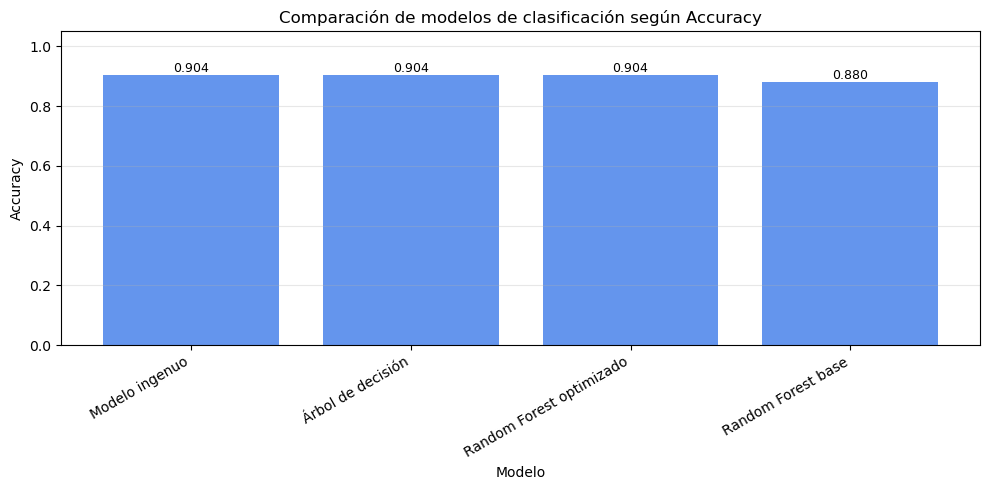

In [140]:
df_accuracy_plot = df_accuracy_clf.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(10, 5))

barras = plt.bar(
    df_accuracy_plot["modelo de clasificación"],
    df_accuracy_plot["Accuracy"],
    color="cornflowerblue"
)

plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.title("Comparación de modelos de clasificación según Accuracy")
plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Interpretación de Accuracy en la gráfica de barras

En la gráfica se observa que el accuracy de los modelos es muy parecido. El modelo ingenuo, el árbol de decisión y el Random Forest optimizado obtuvieron el mismo valor aproximado de 0.904, por lo que tuvieron el mejor desempeño.

El Random Forest base obtuvo un accuracy ligeramente menor, cercano a 0.880. Esto muestra que ajustar los hiperparámetros sí mejoró el Random Forest, pero también que el modelo más complejo no superó claramente al modelo ingenuo ni al árbol de decisión.

En general, los modelos clasificaron correctamente una proporción alta de semanas, alrededor del 90%.

## 8. Matriz de confusión e interpretación para el Random Forest optimizado

Para analizar con más detalle el desempeño del modelo, se utiliza la matriz de confusión del Random Forest optimizado.

En esta matriz:

* Las filas representan las clases reales.
* Las columnas representan las clases predichas.
* La diagonal principal representa los aciertos.
* Los valores fuera de la diagonal representan errores de clasificación.

La matriz permite observar en qué categorías el modelo clasifica correctamente y en cuáles se equivoca.

In [141]:
from sklearn.metrics import confusion_matrix, classification_report

In [142]:
labels = ["bajo", "medio", "alto"]

def matriz_confusion_df(y_real, y_pred, labels):
    cm = confusion_matrix(y_real, y_pred, labels=labels)
    
    df_cm = pd.DataFrame(
        cm,
        index=[f"Real {l}" for l in labels],
        columns=[f"Pred {l}" for l in labels]
    )
    
    return df_cm

In [143]:
df_cm_rf_opt = matriz_confusion_df(
    y_test_clf,
    pred_rf_clf_opt,
    labels
)

df_cm_rf_opt

,Pred bajo,Pred medio,Pred alto
Real bajo,1,0,2
Real medio,1,19,3
Real alto,1,1,55


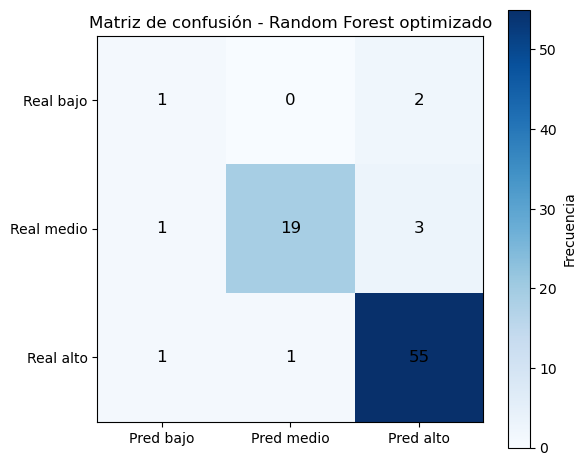

In [144]:
plt.figure(figsize=(6, 5))

plt.imshow(df_cm_rf_opt, cmap="Blues")

plt.xticks(range(len(labels)), [f"Pred {l}" for l in labels])
plt.yticks(range(len(labels)), [f"Real {l}" for l in labels])

plt.title("Matriz de confusión - Random Forest optimizado")
plt.colorbar(label="Frecuencia")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            df_cm_rf_opt.iloc[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()

### Análisis de la matriz de confusión

La matriz de confusión muestra que el modelo Random Forest optimizado clasifica muy bien las semanas de **riesgo alto**. De 57 semanas reales de riesgo alto, clasificó correctamente 55. Esto indica que el modelo detecta adecuadamente las semanas más críticas.

Para la clase **riesgo medio**, el desempeño también es bueno. De 23 semanas reales de riesgo medio, el modelo acertó en 19. Los errores fueron pocos: 1 semana media fue clasificada como bajo y 3 como alto.

La clase con peor desempeño fue **riesgo bajo**. De 3 semanas reales de riesgo bajo, solo 1 fue clasificada correctamente, mientras que 2 fueron clasificadas como riesgo alto. Esto indica que el modelo tiene dificultad para identificar semanas de bajo riesgo.

En general, el modelo tiende a clasificar muchas semanas como **riesgo alto**. En un contexto epidemiológico, esto puede ser útil porque ayuda a no dejar pasar semanas críticas, pero también puede generar falsas alarmas cuando semanas de bajo riesgo se clasifican como alto.

In [145]:
print("Reporte de clasificación - Random Forest optimizado")
print(classification_report(
    y_test_clf,
    pred_rf_clf_opt,
    labels=labels
))

Reporte de clasificación - Random Forest optimizado
              precision    recall  f1-score   support

        bajo       0.33      0.33      0.33         3
       medio       0.95      0.83      0.88        23
        alto       0.92      0.96      0.94        57

    accuracy                           0.90        83
   macro avg       0.73      0.71      0.72        83
weighted avg       0.90      0.90      0.90        83



### Análisis del reporte de clasificación

El Random Forest optimizado tuvo un accuracy de 0.90, así que en general clasificó bien las semanas de prueba.

La clase que mejor detecta es `alto`, con recall de 0.96 y F1-score de 0.94. Esto es importante porque significa que casi no deja pasar semanas de alto riesgo.

La clase `medio` también salió bien, con precision de 0.95 y F1-score de 0.88. O sea, cuando predice riesgo medio, casi siempre acierta, aunque todavía se le escapan algunas semanas.

La clase más débil fue `bajo`, con precision, recall y F1-score de 0.33. Pero también hay que considerar que solo hubo 3 semanas reales de riesgo bajo, entonces con pocos errores las métricas bajan mucho.

En resumen, el modelo funciona bien para riesgo medio y alto, pero no tanto para riesgo bajo. Para este problema, lo más importante es que sí detecta bastante bien las semanas de riesgo alto.

In [146]:
reporte_rf = classification_report(
    y_test_clf,
    pred_rf_clf_opt,
    labels=labels,
    output_dict=True
)

df_reporte_rf = pd.DataFrame(reporte_rf).transpose()

df_reporte_rf

,precision,recall,f1-score,support
bajo,0.333333,0.333333,0.333333,3.000000
medio,0.950000,0.826087,0.883721,23.000000
alto,0.916667,0.964912,0.940171,57.000000
accuracy,0.903614,0.903614,0.903614,0.903614
macro avg,0.733333,0.708111,0.719075,83.000000
weighted avg,0.904819,0.903614,0.902594,83.000000


### Análisis del reporte de clasificación

El modelo tuvo un accuracy de 0.9036, entonces en general clasificó bien, con alrededor del 90% de aciertos.

La clase que mejor detecta es `alto`, con recall de 0.9649 y F1-score de 0.9402. Esto es bueno porque significa que casi sí identifica las semanas de mayor riesgo.

La clase `medio` también salió bastante bien, con precision de 0.95 y F1-score de 0.8837. Aun así, algunas semanas medias se confunden con otra categoría.

La clase más floja fue `bajo`, con precision, recall y F1-score de 0.3333. Pero solo había 3 semanas reales de riesgo bajo, entonces con pocos errores la métrica cae mucho.

En resumen, el modelo funciona bien para riesgo medio y alto, sobre todo para riesgo alto. El problema principal es que no identifica tan bien las semanas de riesgo bajo.

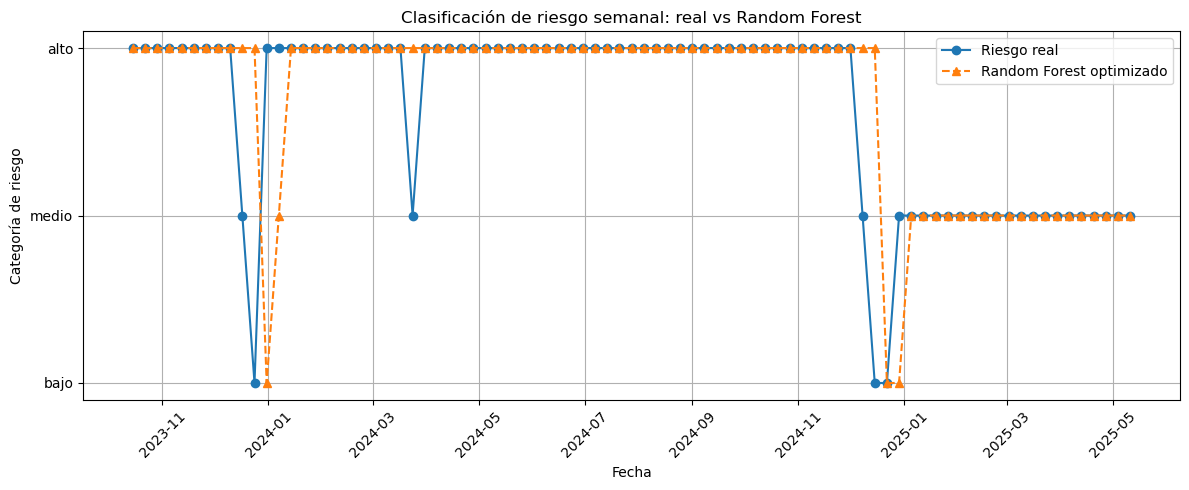

In [150]:
mapa_riesgo = {
    "bajo": 0,
    "medio": 1,
    "alto": 2
}

df_grafica_clf = df_test_clf.copy()

df_grafica_clf["riesgo_real_num"] = y_test_clf.map(mapa_riesgo)

df_grafica_clf["riesgo_rf_num"] = pd.Series(
    pred_rf_clf_opt,
    index=y_test_clf.index
).map(mapa_riesgo)
plt.figure(figsize=(12, 5))

plt.plot(
    df_grafica_clf["FECHA"],
    df_grafica_clf["riesgo_real_num"],
    marker="o",
    label="Riesgo real"
)

plt.plot(
    df_grafica_clf["FECHA"],
    df_grafica_clf["riesgo_rf_num"],
    marker="^",
    linestyle="--",
    label="Random Forest optimizado"
)

plt.yticks([0, 1, 2], ["bajo", "medio", "alto"])

plt.xlabel("Fecha")
plt.ylabel("Categoría de riesgo")
plt.title("Clasificación de riesgo semanal: real vs Random Forest")
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación de la matriz de confusión y la gráfica de datos reales vs modelados

De acuerdo con la matriz de confusión, la clase que mejor se predice es `alto`. El modelo clasificó correctamente 55 de 57 semanas reales de riesgo alto, por lo que detecta bastante bien las semanas más críticas.

La clase `medio` también tiene un buen desempeño. De 23 semanas reales de riesgo medio, el modelo clasificó correctamente 19. Sin embargo, algunas semanas medias fueron confundidas con riesgo alto y una con riesgo bajo.

La clase que más se confunde es `bajo`. De 3 semanas reales de riesgo bajo, solo 1 fue clasificada correctamente, mientras que 2 fueron clasificadas como riesgo alto. Esto muestra que el modelo tiene más dificultad para reconocer semanas de bajo riesgo.

En general, el modelo sí detecta bien las semanas de riesgo alto, lo cual es importante en un contexto epidemiológico. Es preferible que el modelo sea sensible a semanas de alto riesgo, porque no detectarlas podría llevar a subestimar una situación importante.

Sin embargo, también se observa que el modelo puede generar falsas alarmas, especialmente cuando clasifica semanas de bajo riesgo como alto. En un contexto epidemiológico, esto implicaría tomar precauciones adicionales aunque el riesgo real no sea tan alto.

## 9. Importancia de variables

Para el modelo Random Forest optimizado también se analiza la importancia de las variables predictoras.

La importancia de variables indica qué variables fueron más utilizadas por el modelo para separar las semanas en riesgo bajo, medio o alto.

In [152]:
variables_predictoras = [
    "CASOS_NACIONALES",
    "CAMBIO_SEMANAL",
    "promedio_movil_3",
    "promedio_movil_5",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4"
]
importancias = pd.DataFrame({
    "variable": variables_predictoras,
    "importancia": modelo_rf_clf_opt.feature_importances_
})

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

importancias

,variable,importancia
0,CASOS_NACIONALES,0.311416
2,promedio_movil_3,0.281275
4,lag_1,0.137751
3,promedio_movil_5,0.095525
6,lag_3,0.054973
5,lag_2,0.050192
7,lag_4,0.035835
1,CAMBIO_SEMANAL,0.033033


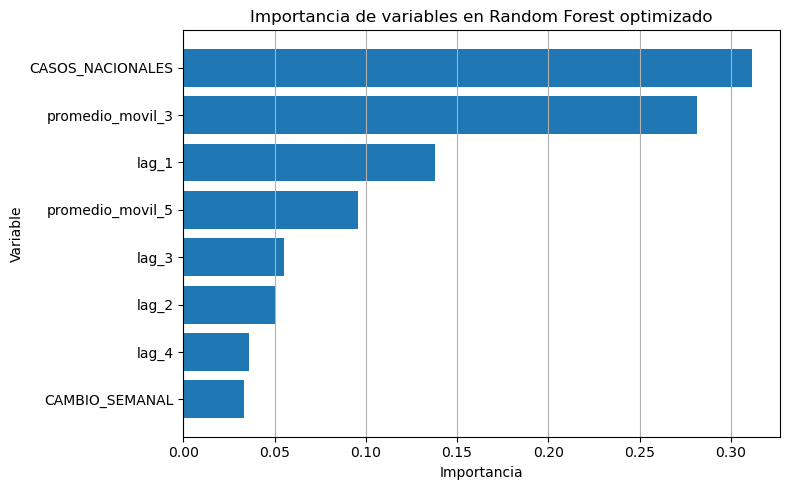

In [153]:
plt.figure(figsize=(8, 5))

plt.barh(
    importancias["variable"],
    importancias["importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables en Random Forest optimizado")
plt.grid(axis="x")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Parte 7. Importancia de variables

En el modelo **Random Forest optimizado**, la importancia de variables muestra qué variables fueron más utilizadas por el modelo para separar o clasificar correctamente los datos.

## ¿Cuál fue la variable más importante?

La variable más importante fue **CASOS_NACIONALES**, con una importancia aproximada de **0.31**.

Esto indica que el número de casos nacionales actuales fue la variable que más peso tuvo dentro del modelo para realizar la predicción.

## ¿Los casos actuales \(C_t\) fueron más importantes que los rezagos?

Sí.  
Los **casos actuales**, representados por **CASOS_NACIONALES**, fueron más importantes que todos los rezagos.

Los rezagos tuvieron menor importancia:

- **lag_1** fue el rezago más importante, con una importancia aproximada de **0.14**.
- Después siguieron **lag_3**, **lag_2** y **lag_4**, todos con valores mucho menores.
- Esto sugiere que el modelo usa más la información actual que la información de días anteriores.

Sin embargo, los rezagos sí aportan información, especialmente **lag_1**, porque el comportamiento reciente de los casos puede ayudar a anticipar la clase o categoría objetivo.

## ¿Los promedios móviles aportaron información?

Sí.  
Los promedios móviles aportaron bastante información al modelo.

En particular:

- **promedio_movil_3** fue la segunda variable más importante, con una importancia aproximada de **0.28**.
- **promedio_movil_5** también tuvo una importancia considerable, cercana a **0.10**.

Esto indica que el modelo no solo toma en cuenta el valor actual de los casos, sino también la tendencia reciente suavizada.  
El promedio móvil de 3 días fue más relevante que el de 5 días, por lo que parece que la tendencia de corto plazo aportó más información que una tendencia un poco más amplia.

## ¿El cambio semanal fue relevante?

No fue muy relevante.

La variable **CAMBIO_SEMANAL** tuvo la menor importancia del gráfico, con un valor aproximado de **0.03**.

Esto significa que, comparada con los casos actuales, los promedios móviles y algunos rezagos, el cambio semanal aportó poca información al modelo.  
No necesariamente significa que sea inútil, pero sí que el Random Forest la utilizó mucho menos para tomar decisiones.

## ¿La importancia de variables debe interpretarse como causalidad?

No.

La importancia de variables **no debe interpretarse como causalidad**.  
Que una variable tenga alta importancia significa que ayudó al modelo a mejorar sus predicciones, pero no significa que esa variable sea la causa directa del resultado.

Por ejemplo, que **CASOS_NACIONALES** sea la variable más importante no implica que por sí sola cause la clasificación obtenida. Solo indica que contiene mucha información útil para el modelo.

## Interpretación general

El modelo Random Forest optimizado depende principalmente de la información actual de los casos y de la tendencia reciente. La variable más importante fue **CASOS_NACIONALES**, seguida por **promedio_movil_3**. Esto muestra que el modelo utiliza tanto el nivel actual de contagios como el comportamiento suavizado de los últimos días.

Los rezagos también aportaron información, especialmente **lag_1**, aunque en menor medida que los casos actuales y el promedio móvil de 3 días. El **cambio semanal** fue la variable menos relevante, por lo que su contribución al modelo fue limitada.

En conclusión, el modelo se apoya principalmente en los casos actuales y en las tendencias recientes, pero estas importancias solo deben entenderse como utilidad predictiva, no como relaciones causales.

## 10. Conclusiones finales

## 1. ¿Qué se observó en la serie nacional de dengue?

En la serie nacional de dengue se observó un comportamiento variable, con aumentos y disminuciones importantes a lo largo del tiempo. Los casos no se mantuvieron constantes, sino que presentaron picos fuertes, especialmente en algunos periodos como finales de 2023 y 2024.

También se observó que los cambios bruscos dificultan la predicción, porque el comportamiento de la serie no siempre sigue una tendencia suave.

## 2. ¿Qué modelo funcionó mejor para predecir casos?

Para la predicción de casos, los mejores modelos fueron los modelos simples.

El **modelo ingenuo** tuvo el menor **MAE**, por lo que en promedio cometió menos error.  
La **regresión lineal** tuvo el menor **RMSE**, por lo que manejó mejor los errores grandes.

Por lo tanto, para predecir casos, no se puede decir que el Random Forest haya sido claramente el mejor. En este análisis, los modelos simples funcionaron mejor que los modelos más complejos.

## 3. ¿Qué modelo funcionó mejor para clasificar riesgo?

Para clasificar el riesgo, los mejores modelos fueron:

- Modelo ingenuo
- Árbol de decisión
- Random Forest optimizado

Estos modelos obtuvieron un accuracy aproximado de **0.9036**, es decir, clasificaron correctamente alrededor del **90.36%** de las semanas del conjunto de prueba.

El Random Forest optimizado fue útil porque además permitió analizar la matriz de confusión y la importancia de variables.

## 4. ¿El modelo más complejo fue siempre el mejor?

No.

El modelo más complejo no fue siempre el mejor. En regresión, Random Forest no superó claramente al modelo ingenuo ni a la regresión lineal. En clasificación, el Random Forest optimizado tuvo buen desempeño, pero obtuvo el mismo accuracy que el modelo ingenuo y el árbol de decisión.

Esto muestra que usar un modelo más avanzado no garantiza mejores resultados.

## 5. ¿Qué tan útil fue el modelo ingenuo?

El modelo ingenuo fue bastante útil.

En predicción de casos, funcionó muy bien porque la serie de dengue tiene continuidad temporal: si una semana tiene cierto número de casos, la siguiente semana suele tener un valor parecido.

En clasificación de riesgo, el modelo ingenuo también fue competitivo, ya que obtuvo un accuracy alto. Esto indica que mantener la categoría de riesgo de la semana anterior fue una estrategia simple, pero efectiva.

## 6. ¿Qué variables fueron más importantes?

En el Random Forest optimizado, las variables más importantes fueron:

1. **CASOS_NACIONALES**
2. **promedio_movil_3**
3. **lag_1**
4. **promedio_movil_5**

La variable más importante fue **CASOS_NACIONALES**, lo que indica que los casos actuales aportaron mucha información para clasificar el riesgo.

Los promedios móviles también fueron relevantes, especialmente el promedio móvil de 3 semanas. Esto muestra que la tendencia reciente ayudó al modelo.

El **CAMBIO_SEMANAL** fue la variable menos importante, por lo que tuvo poca relevancia comparada con las demás variables.

## 7. ¿Qué limitaciones tiene el análisis?

El análisis tiene varias limitaciones:

- Solo se usaron casos históricos de dengue.
- No se incluyeron variables climáticas, sociales o geográficas.
- La serie presenta picos bruscos difíciles de predecir.
- El conjunto de prueba tuvo muchas semanas de riesgo alto y pocas de riesgo bajo.
- Las métricas pueden verse afectadas por el desbalance entre clases.
- La importancia de variables no debe interpretarse como causalidad.
- Los resultados dependen de la forma en que se dividieron los datos en entrenamiento y prueba.

## 8. ¿Qué información adicional podría mejorar los modelos?

Los modelos podrían mejorar si se agregara información adicional como:

- Temperatura.
- Precipitación.
- Humedad.
- Temporada de lluvias.
- Información por estado o región.
- Densidad poblacional.
- Campañas de fumigación o prevención.
- Datos de movilidad.
- Variables ambientales relacionadas con la reproducción del mosquito.

## Conclusión general

En conclusión, la serie nacional de dengue mostró un comportamiento irregular, con picos importantes y cambios bruscos. Para predecir casos, los modelos simples como el modelo ingenuo y la regresión lineal fueron más competitivos que los modelos complejos. Para clasificar riesgo, el Random Forest optimizado tuvo buen desempeño, aunque no superó claramente al modelo ingenuo ni al árbol de decisión.

El análisis muestra que la información más útil para el modelo fue el número actual de casos y la tendencia reciente medida con promedios móviles. Sin embargo, los resultados deben interpretarse con cuidado, porque la importancia de variables no implica causalidad y porque el modelo solo usa información histórica de casos. Para mejorar el desempeño sería necesario incluir variables externas, especialmente climáticas y epidemiológicas.